In [ ]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Set visual style for plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
# Fix all sources of randomness for reproducibility
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)
print(f"Random seed fixed to: {SEED}")

Random seed fixed to: 42


In [ ]:
# Load raw dataset using pandas
data_path = "./data/diabetic_data.csv"
df = pd.read_csv(data_path)

print(f"Raw dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Raw dataset shape: 101766 rows, 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
# Cell 4: Statistical summary using describe()
print("--- Numerical Attributes Summary ---")
display(df.describe())

print("--- Categorical Attributes Summary ---")
display(df.describe(include=['O']))

--- Numerical Attributes Summary ---


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


--- Categorical Attributes Summary ---


,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,101766,101766,101766,101766,101766,101766,101766,101766,101766,5346,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,6,3,10,10,18,73,717,749,790,3,...,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),?,?,?,428,276,250,Norm,...,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,98569,40256,49949,6862,6752,11555,2597,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


## Managing missing/unknown values and useless columns

Missing values statistics before cleaning

--- Attributes with Missing Values (NaN) Before Cleaning ---


,Missing_Count,Missing_Percentage (%)
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636
gender,3,0.002948


/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/2104288300.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


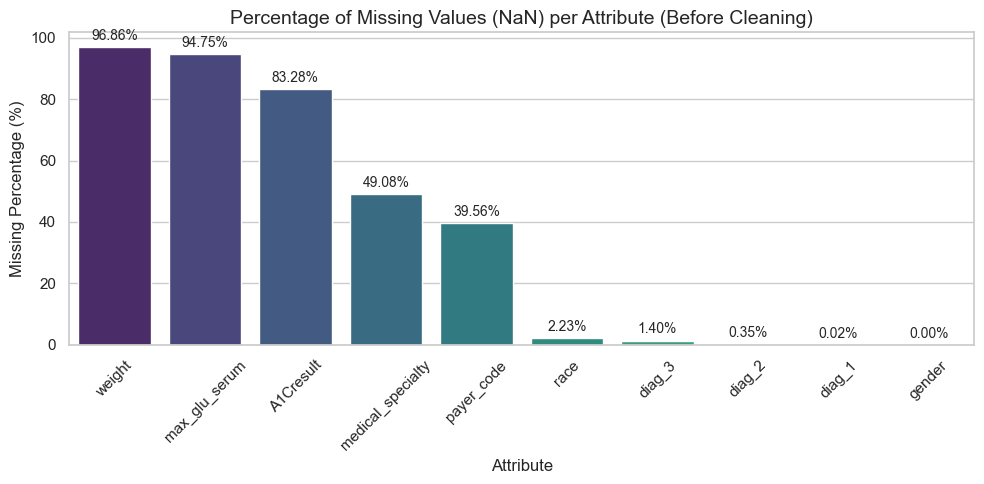

In [6]:
# Replace '?' with NaN for standard missing value processing
df.replace('?', np.nan, inplace=True)
df.replace('Unknown/Invalid', np.nan, inplace=True)

missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percentage (%)': missing_pct
}).sort_values(by='Missing_Percentage (%)', ascending=False)

missing_df_filtered = missing_df[missing_df['Missing_Count'] > 0]
print("--- Attributes with Missing Values (NaN) Before Cleaning ---")
display(missing_df_filtered)

# Plot missing value percentages using seaborn
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=missing_df_filtered.index,
    y='Missing_Percentage (%)',
    data=missing_df_filtered,
    palette='viridis'
)
plt.title('Percentage of Missing Values (NaN) per Attribute (Before Cleaning)', fontsize=14)
plt.xlabel('Attribute', fontsize=12)
plt.ylabel('Missing Percentage (%)', fontsize=12)
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

### Missing Values Strategy & Feature Removal

**Handling Highly Incomplete Features:**
- **`weight`**: Removed entirely from the dataset due to an extreme missing value rate (>97%). Imputing such a vast majority of missing values would introduce substantial noise and artificial bias.

**Clinical Meaningfulness of Unmeasured Lab Tests:**
- **`max_glu_serum` & `A1Cresult`**: Missing values in glucose and HbA1c tests do not represent random data loss, but rather an explicit clinical decision by the attending physician that an immediate measurement was not required. Consequently, `NaN` values are explicitly imputed with the category `'Not measured'` to preserve this implicit diagnostic signal.

**Categorical Imputation:**
- **`race`**, **`payer_code`**, **`medical_specialty`**, **`diag_2`**, **`diag_3`**: Missing values are imputed with the category `'Unknown'` to preserve patient records without making arbitrary statistical assumptions.

**Filtering Incomplete Primary Records:**
- **`diag_1`**: Encounters missing the primary diagnosis (`diag_1`) are dropped. Since `diag_1` represents the primary reason for hospital admission and missing instances are negligible (<0.02%), retaining unlabelled primary admissions is clinically uninformative.

In [ ]:
# Drop weight column
df.drop(columns=['weight'], inplace=True)

# Remove rows where diag_1 or gender is NaN
df = df.dropna(subset=['diag_1'])
df = df.dropna(subset=['gender'])


# Replace Nan with 'Not measured' in max_glu_serum and A1Cresult
df['max_glu_serum'] = df['max_glu_serum'].replace(np.nan, 'Not measured')
df['A1Cresult'] = df['A1Cresult'].replace(np.nan, 'Not measured')

# Set 'Unknown' for NaNs in race, diag_2, diag_3, medical_specialty and payer_code
df['race'] = df['race'].fillna('Unknown')
df['diag_2'] = df['diag_2'].fillna('Unknown')
df['diag_3'] = df['diag_3'].fillna('Unknown')
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')
df['payer_code'] = df['payer_code'].fillna('Unknown')


print(f"Cleaned dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Remaining NaNs in cleaned dataset: {df.isnull().sum().sum()}")

Cleaned dataset shape: 101742 rows, 49 columns
Remaining NaNs in cleaned dataset: 0


In [8]:
# Remove constant columns (columns with only one unique value)
print(f"Number of columns before removing constant columns: {df.shape[1]}")
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
df = df.drop(columns=constant_cols)
print(f"Number of columns after removing constant columns: {df.shape[1]}")

# print which columns were removed
print(f"Removed constant columns: {constant_cols}")
print(f"Final cleaned dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")


Number of columns before removing constant columns: 49
Number of columns after removing constant columns: 47
Removed constant columns: ['examide', 'citoglipton']
Final cleaned dataset shape: 101742 rows, 47 columns


In [9]:
# Check total encounters and unique patients before deduplication
total_encounters_before = len(df)
unique_patients_before = df['patient_nbr'].nunique()

print(f"Total encounters before deduplication: {total_encounters_before:,}")
print(f"Unique patients before deduplication:   {unique_patients_before:,}")
print(f"Duplicate encounters to be removed:    {total_encounters_before - unique_patients_before:,}\n")

# Ensure chronological order by encounter_id and retain only the first encounter per patient
df = df.sort_values(by='encounter_id').reset_index(drop=True)
df = df.drop_duplicates(subset=['patient_nbr'], keep='first').reset_index(drop=True)

# Verify deduplication results
total_encounters_after = len(df)
unique_patients_after = df['patient_nbr'].nunique()

print("=== DEDUPLICATION RESULTS ===")
print(f"Final dataset rows (first encounters only): {total_encounters_after:,}")
print(f"Final unique patient count:                 {unique_patients_after:,}")

# Assertion check to guarantee exactly one row per patient
assert total_encounters_after == unique_patients_after, "Deduplication failed: row count does not match unique patient count!"
print("Deduplication successfully verified: Exactly 1 record per patient retained.")
print(f"Final cleaned dataset shape after deduplication: {df.shape[0]} rows, {df.shape[1]} columns")

Total encounters before deduplication: 101,742
Unique patients before deduplication:   71,506
Duplicate encounters to be removed:    30,236

=== DEDUPLICATION RESULTS ===
Final dataset rows (first encounters only): 71,506
Final unique patient count:                 71,506
Deduplication successfully verified: Exactly 1 record per patient retained.
Final cleaned dataset shape after deduplication: 71506 rows, 47 columns


## Plotting distibutions

=== NUMERICAL VARIABLES DISTRIBUTION ===


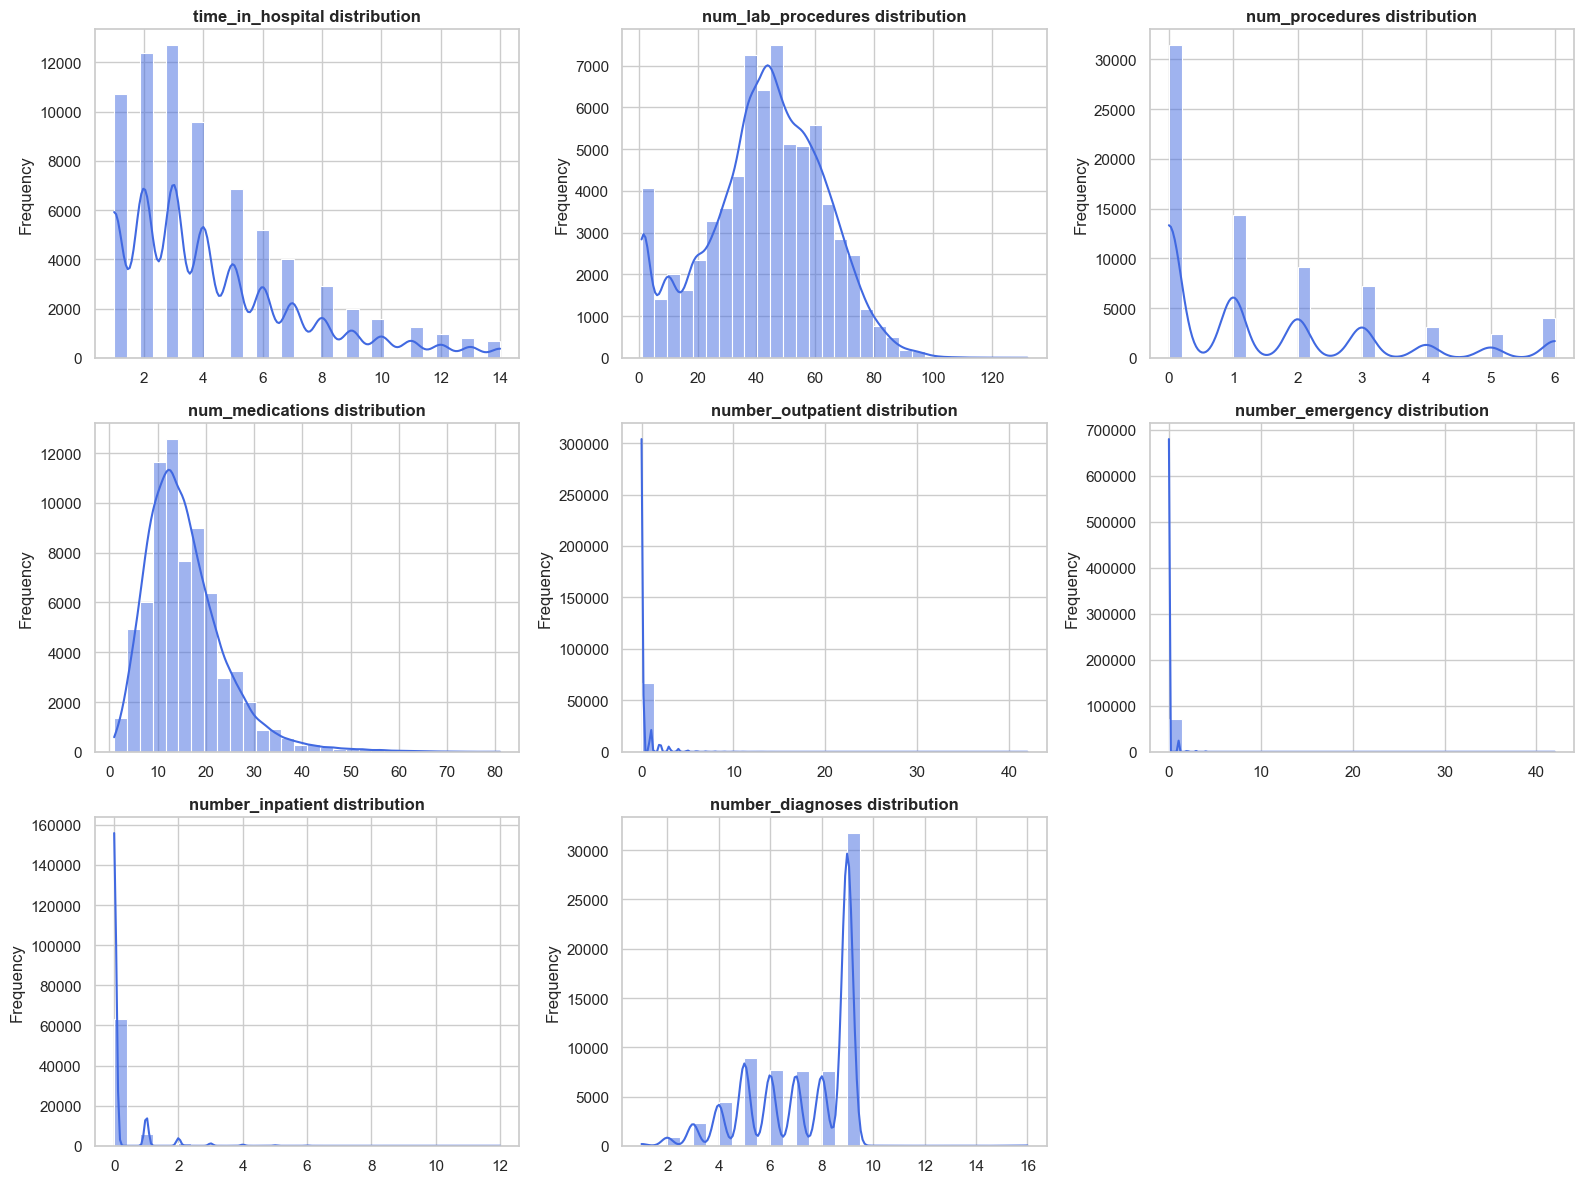


--- Skewness Index ---
Note: values > 1 or < -1 indicate high skewness.
- time_in_hospital          Skewness:   1.17  (High Skewness)
- num_lab_procedures        Skewness:  -0.22  (Moderate/Symmetric)
- num_procedures            Skewness:   1.22  (High Skewness)
- num_medications           Skewness:   1.43  (High Skewness)
- number_outpatient         Skewness:   9.68  (High Skewness)
- number_emergency          Skewness:  21.15  (High Skewness)
- number_inpatient          Skewness:   5.55  (High Skewness)
- number_diagnoses          Skewness:  -0.74  (Moderate/Symmetric)


=== CATEGORICAL VARIABLES DISTRIBUTION ===


/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/1183897019.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, ax=axes[i], order=order, palette='crest')
/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/1183897019.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, ax=axes[i], order=order, palette='crest')
/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/1183897019.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, ax=axes[i], order=orde

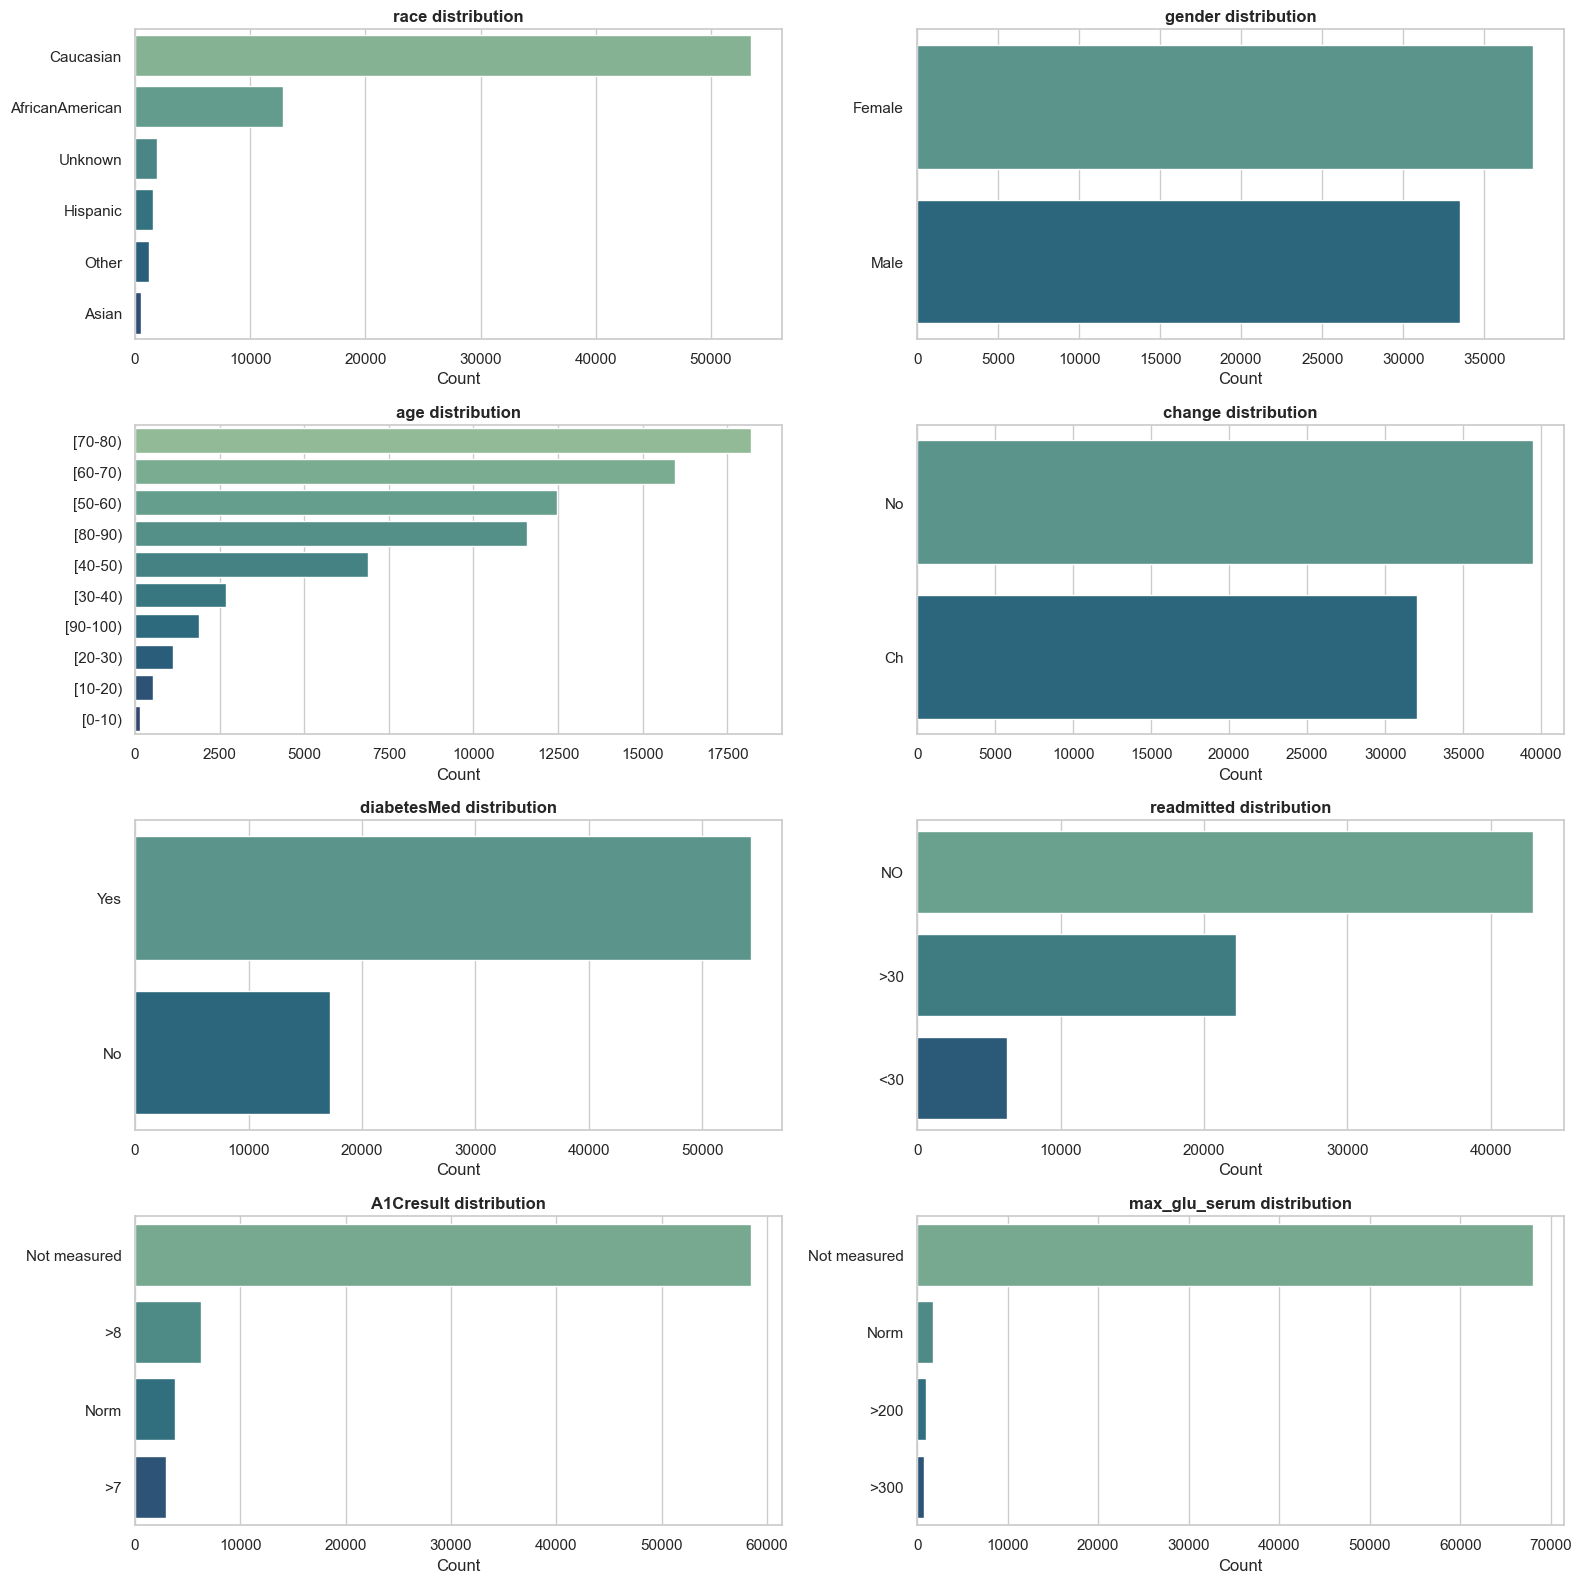

In [10]:
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


print("=== NUMERICAL VARIABLES DISTRIBUTION ===")
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, ax=axes[i], kde=True, bins=30, color='royalblue')
    axes[i].set_title(f'{col} distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# Remove any empty plots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Calculate quantitative skewness (asymmetry)
print("\n--- Skewness Index ---")
print("Note: values > 1 or < -1 indicate high skewness.")
for col in num_cols:
    skew_val = df[col].skew()
    status = "High Skewness" if abs(skew_val) > 1 else "Moderate/Symmetric"
    print(f"- {col:<25} Skewness: {skew_val:>6.2f}  ({status})")

print("\n" + "="*50 + "\n")


cat_cols = ['race', 'gender', 'age', 'change', 'diabetesMed', 'readmitted', 'A1Cresult', 'max_glu_serum']

print("=== CATEGORICAL VARIABLES DISTRIBUTION ===")
n_cols = 2
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Get the order of categories based on their counts for better visualization
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, ax=axes[i], order=order, palette='crest')
    axes[i].set_title(f'{col} distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

# Remove any empty plots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/1929700775.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=['No', 'Steady', 'Up', 'Down'], palette='Set2')
/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/1929700775.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=['No', 'Steady', 'Up', 'Down'], palette='Set2')
/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/1929700775.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.

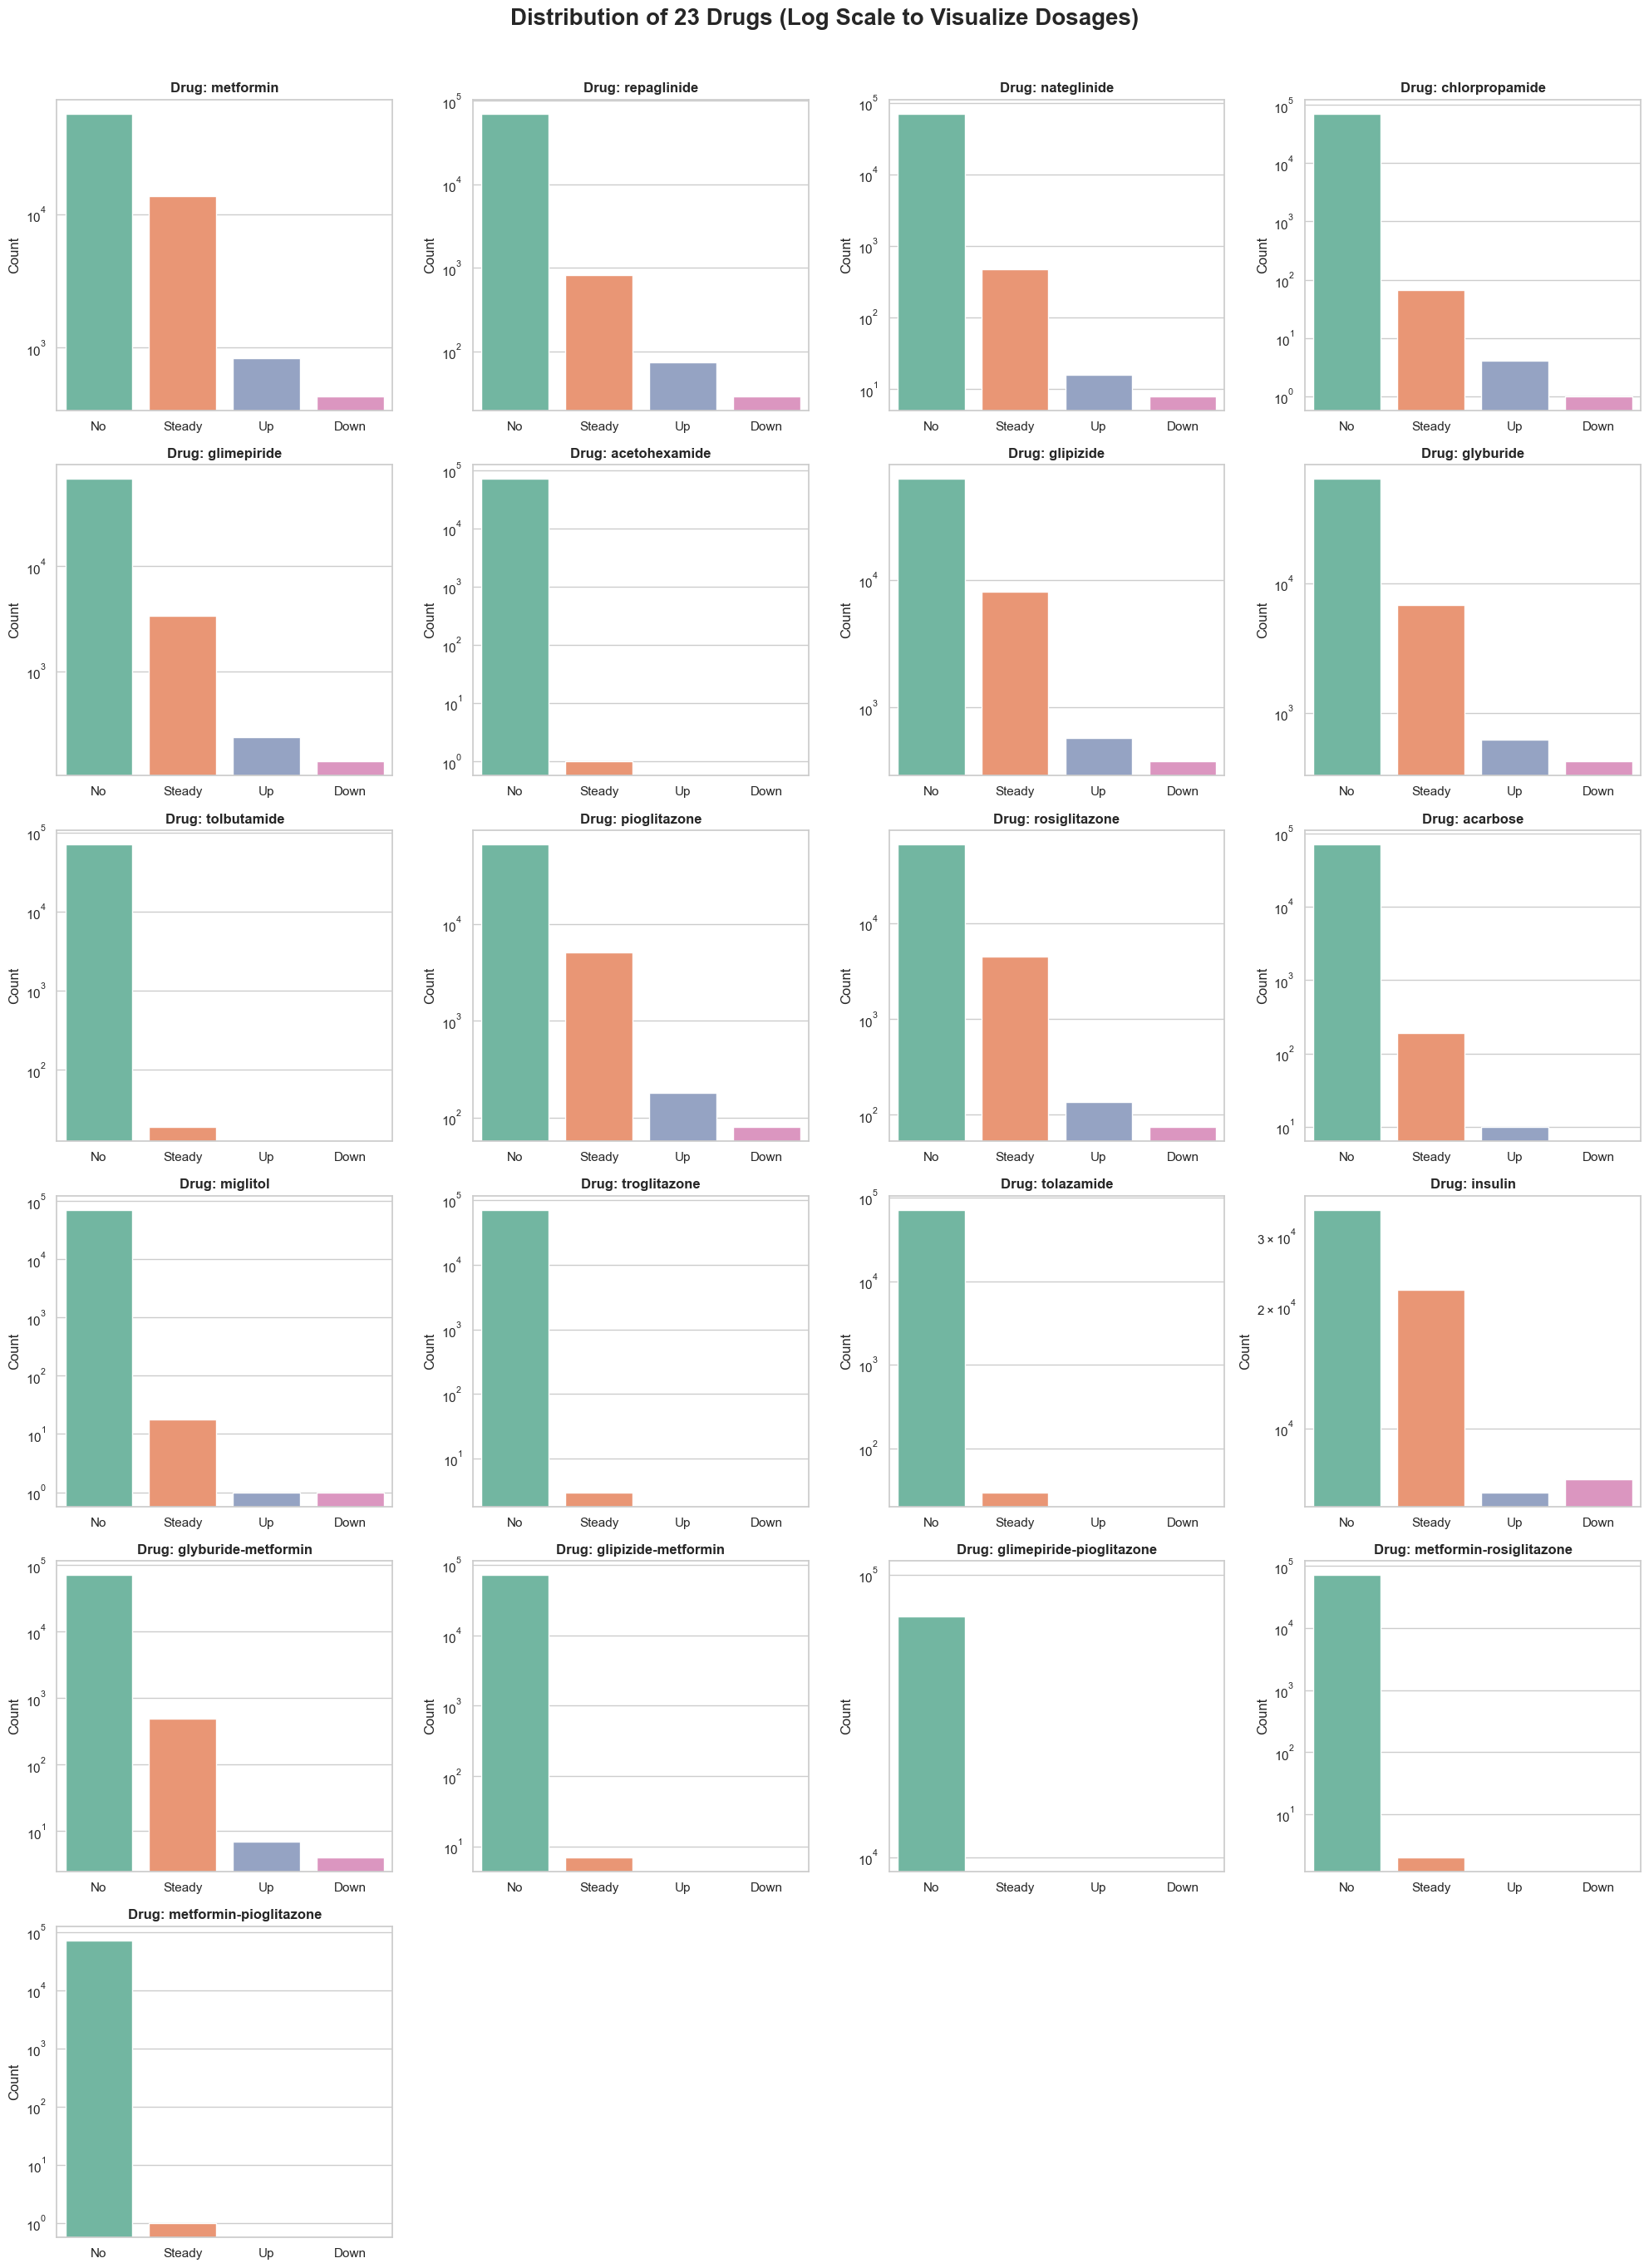

In [ ]:
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
            'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
            'insulin', 'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


n_cols = 4
n_rows = math.ceil(len(med_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4.5))
axes = axes.flatten()

for i, col in enumerate(med_cols):
    sns.countplot(data=df, x=col, ax=axes[i], order=['No', 'Steady', 'Up', 'Down'], palette='Set2')
    axes[i].set_title(f'Drug: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].set_yscale('log') 

# Remove last 3 empty subplots
if len(axes) > len(med_cols):
    fig.delaxes(axes[-1])
    fig.delaxes(axes[-2])
    fig.delaxes(axes[-3])


plt.suptitle("Distribution of 23 Drugs (Log Scale to Visualize Dosages)", fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/1558834024.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, palette='viridis')


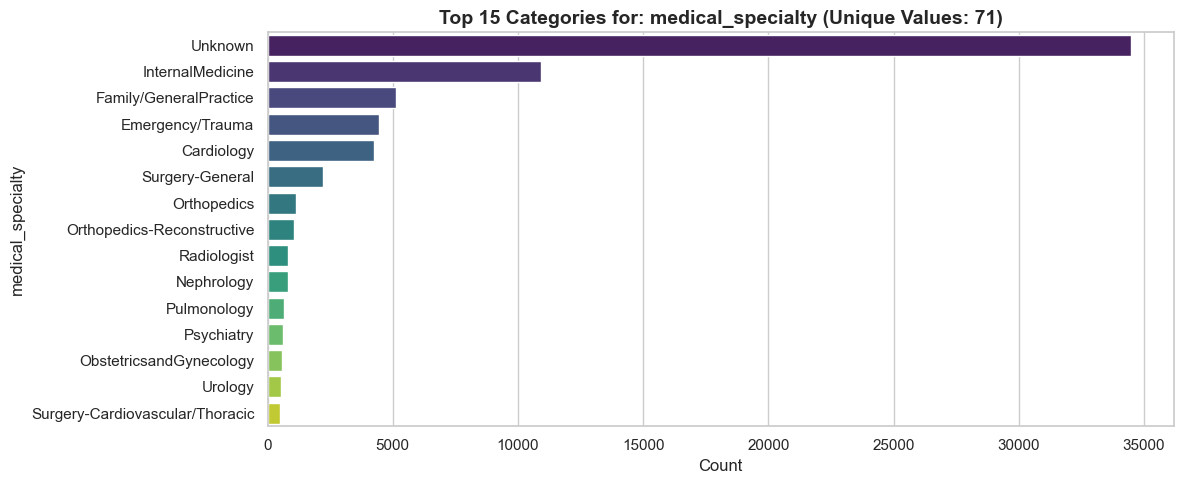

/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/1558834024.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, palette='viridis')


Column: medical_specialty
- Total unique values in the dataset: 71
- The top 15 categories cover 95.35% of the entire dataset.
----------------------------------------------------------------------


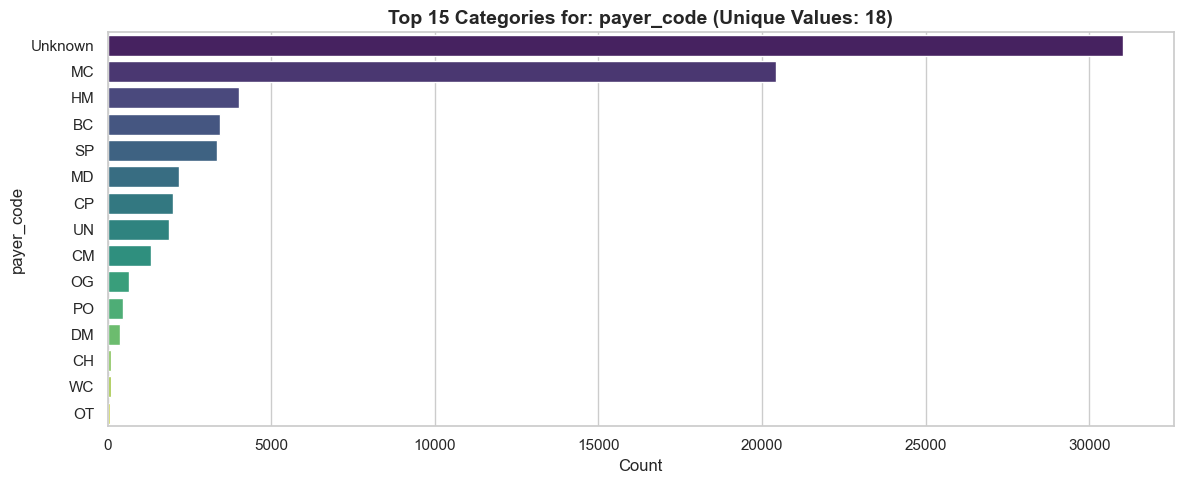

Column: payer_code
- Total unique values in the dataset: 18
- The top 15 categories cover 99.90% of the entire dataset.
----------------------------------------------------------------------


/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/1558834024.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, palette='viridis')


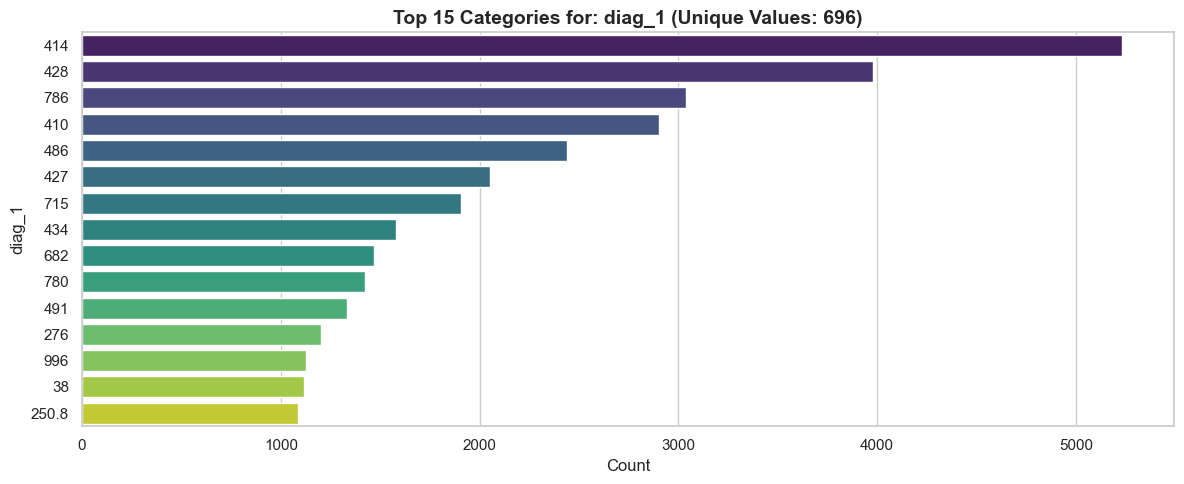

/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/1558834024.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, palette='viridis')


Column: diag_1
- Total unique values in the dataset: 696
- The top 15 categories cover 44.60% of the entire dataset.
----------------------------------------------------------------------


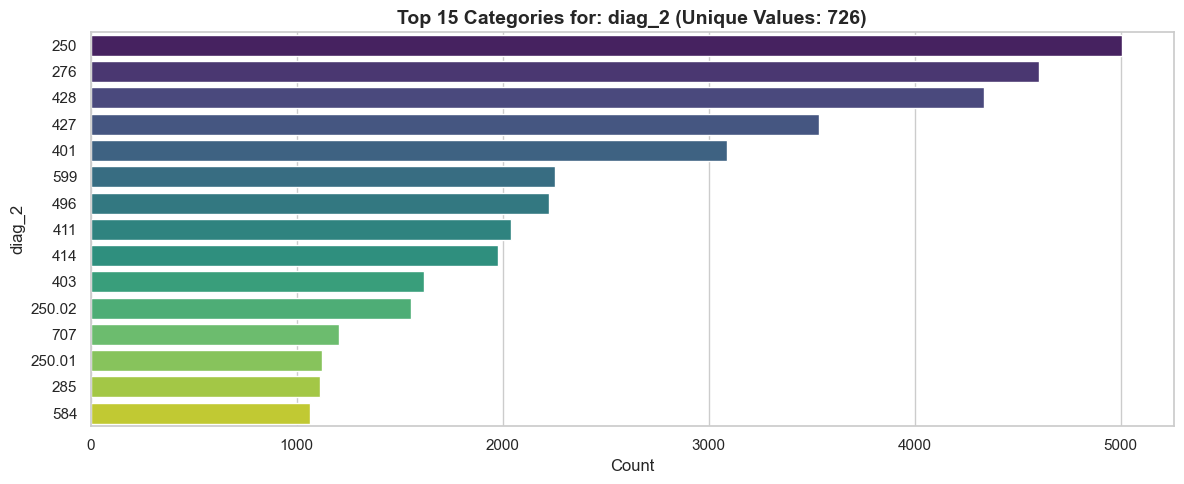

/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/1558834024.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, palette='viridis')


Column: diag_2
- Total unique values in the dataset: 726
- The top 15 categories cover 51.41% of the entire dataset.
----------------------------------------------------------------------


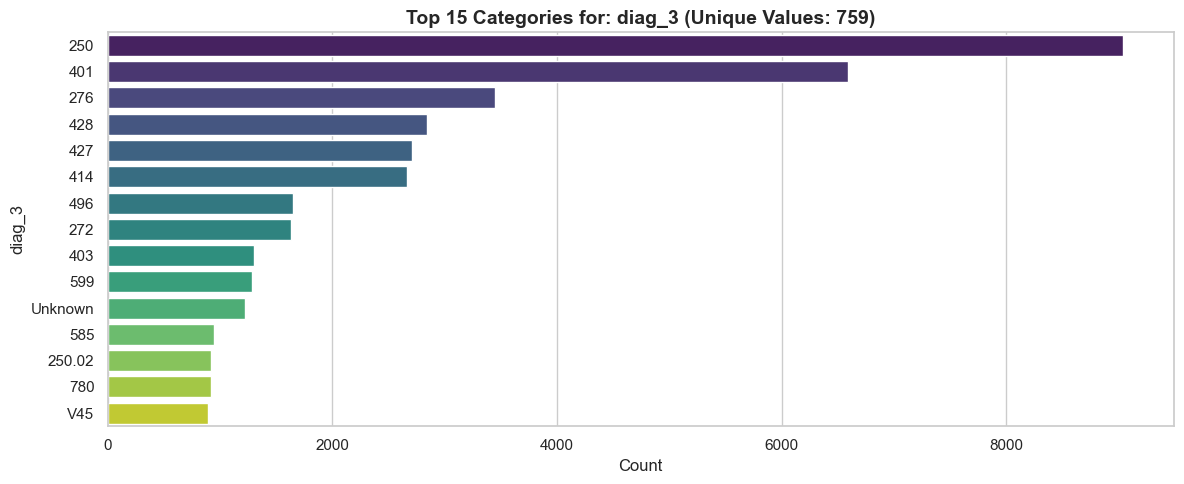

Column: diag_3
- Total unique values in the dataset: 759
- The top 15 categories cover 53.23% of the entire dataset.
----------------------------------------------------------------------


In [12]:
high_card_cols = ['medical_specialty', 'payer_code', 'diag_1', 'diag_2', 'diag_3']

for col in high_card_cols:
    plt.figure(figsize=(12, 5))
    top_values = df[col].value_counts().head(15)
    
    # horizontal bar plot for better readability of names/codes
    sns.barplot(x=top_values.values, y=top_values.index, palette='viridis')
    plt.title(f'Top 15 Categories for: {col} (Unique Values: {df[col].nunique()})', fontsize=14, fontweight='bold')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    
    # percentage coverage calculation
    pct_covered = (top_values.sum() / len(df)) * 100
    print(f"Column: {col}")
    print(f"- Total unique values in the dataset: {df[col].nunique()}")
    print(f"- The top 15 categories cover {pct_covered:.2f}% of the entire dataset.")
    print("-" * 70)

/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/1292649561.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=order, palette='muted')
/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/1292649561.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=order, palette='muted')
/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/1292649561.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=orde

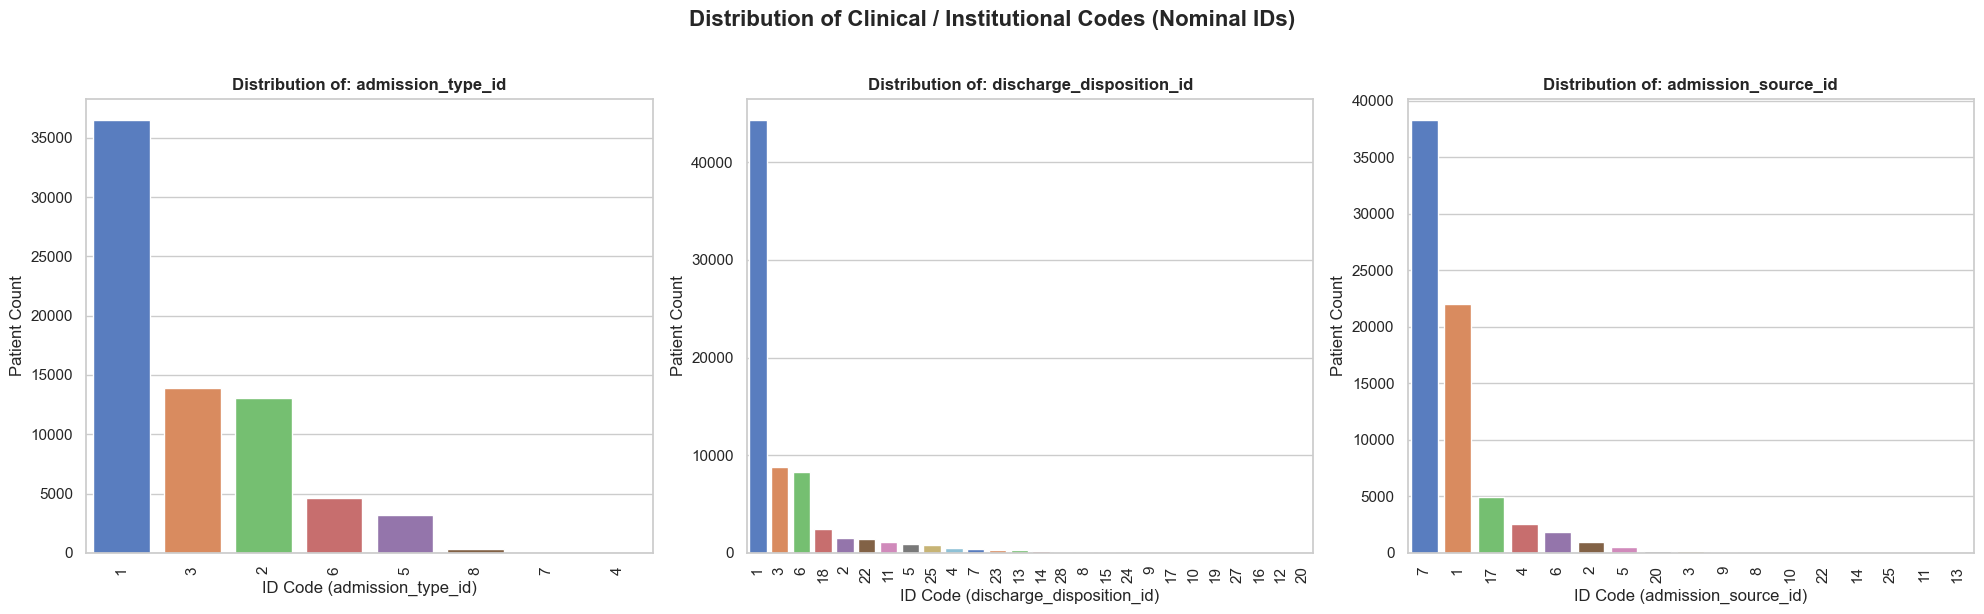

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of the 3 nominal ID columns
id_nominal_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(id_nominal_cols):
    # Order the categories based on their counts for better visualization
    order = df[col].value_counts().index
    
    sns.countplot(data=df, x=col, ax=axes[i], order=order, palette='muted')
    axes[i].set_title(f'Distribution of: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(f'ID Code ({col})')
    axes[i].set_ylabel('Patient Count')
    
    # Ruotiamo le etichette sull'asse X di 90 gradi per evitare che si sovrappongano
    axes[i].tick_params(axis='x', rotation=90)

plt.suptitle("Distribution of Clinical / Institutional Codes (Nominal IDs)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Processing


In [14]:
# Create a new DataFrame to which we will store the cleaned and processed data for further analysis
df_processed = pd.DataFrame()

### Drugs encoding

### Pharmacological Analysis: Investigating Treatment Regimens

**Objective:**
Insulin is the primary medical intervention for advanced diabetes management. To evaluate whether we can simplify the feature space by retaining *only* insulin while discarding the remaining 20 anti-diabetic medications, we conduct an in-depth exploratory analysis of pharmacological regimens across the patient cohort.

**Key Research Questions:**
1. How many patients are treated with **Insulin only**?
2. How many patients receive **Combination Therapy** (Insulin + non-insulin drugs)?
3. How many patients are treated with **Non-insulin medications only**?
4. How many patients receive **No anti-diabetic medication**?

=== DETAILED MEDICATION REGIMEN ANALYSIS ===
Total analyzed patients: 71,506

Insulin ONLY:                          20,028 patients (28.01%)
Insulin + Other Meds (Combination):    16,565 patients (23.17%)
Other Meds ONLY (No Insulin):          17,718 patients (24.78%)
NO Diabetes Medication:                17,195 patients (24.05%)

--- FOCUS ON PATIENTS PRESCRIBED NON-INSULIN MEDICATIONS ---
Total patients taking at least one non-insulin medication: 34,283
  - ALSO taking Insulin (Combination Therapy): 16,565 (48.32%)
  - NOT taking Insulin (Non-insulin Only):     17,718 (51.68%)

-> Percentage of total dataset taking non-insulin meds WITHOUT insulin: 24.78%


/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/1277596690.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bar_x_labels, y=bar_counts, ax=axes[1], palette='Set2')


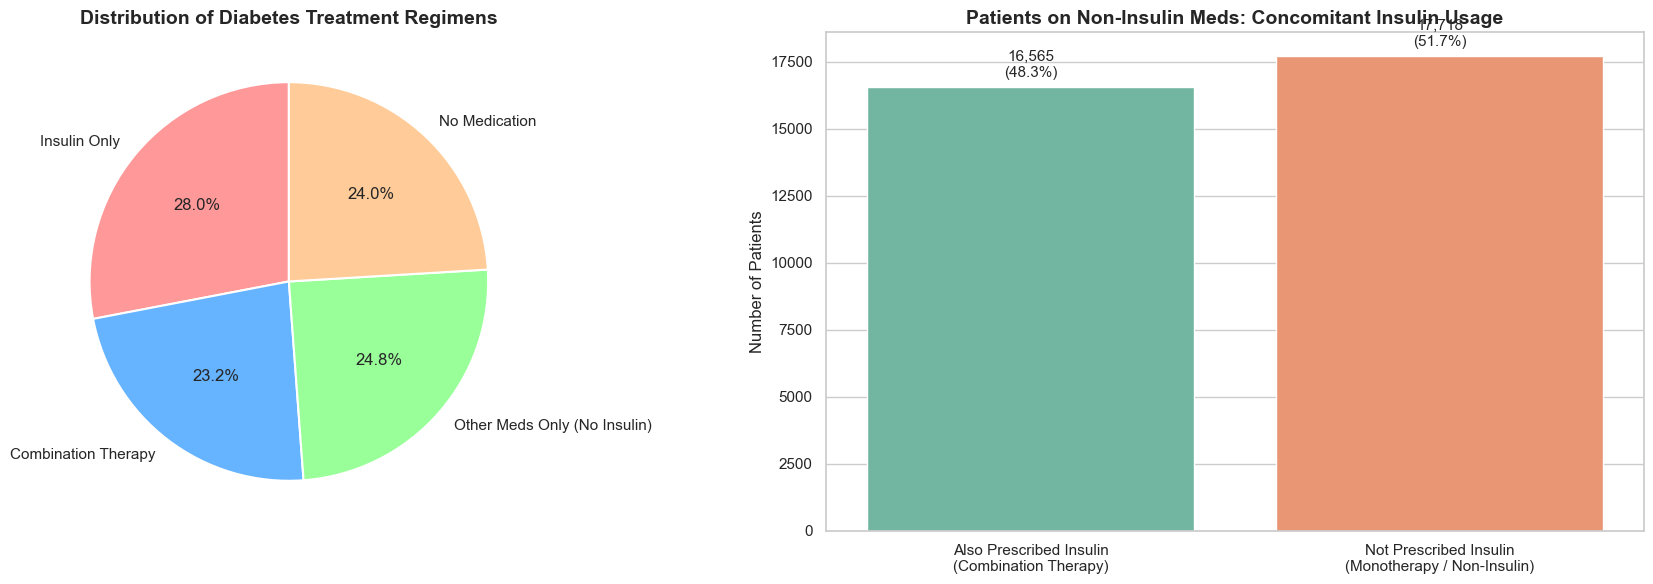

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define medication features excluding insulin
non_insulin_meds = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

# Create temporary boolean helper columns
df['takes_insulin'] = df['insulin'] != 'No'
df['takes_other_meds'] = df[non_insulin_meds].ne('No').any(axis=1)

# Calculate cohort size and mutually exclusive treatment categories
total_patients = len(df)

insulin_only = df[df['takes_insulin'] & ~df['takes_other_meds']].shape[0]
combination_therapy = df[df['takes_insulin'] & df['takes_other_meds']].shape[0]
other_meds_only = df[~df['takes_insulin'] & df['takes_other_meds']].shape[0]
no_medication = df[~df['takes_insulin'] & ~df['takes_other_meds']].shape[0]

# Print detailed summary statistics
print("=== DETAILED MEDICATION REGIMEN ANALYSIS ===")
print(f"Total analyzed patients: {total_patients:,}\n")

print(f"Insulin ONLY:                          {insulin_only:>6,} patients ({insulin_only/total_patients*100:>5.2f}%)")
print(f"Insulin + Other Meds (Combination):    {combination_therapy:>6,} patients ({combination_therapy/total_patients*100:>5.2f}%)")
print(f"Other Meds ONLY (No Insulin):          {other_meds_only:>6,} patients ({other_meds_only/total_patients*100:>5.2f}%)")
print(f"NO Diabetes Medication:                {no_medication:>6,} patients ({no_medication/total_patients*100:>5.2f}%)\n")

# Focus analysis on patients taking non-insulin medications
patients_on_other_meds = combination_therapy + other_meds_only
print("--- FOCUS ON PATIENTS PRESCRIBED NON-INSULIN MEDICATIONS ---")
print(f"Total patients taking at least one non-insulin medication: {patients_on_other_meds:,}")
print(f"  - ALSO taking Insulin (Combination Therapy): {combination_therapy:,} ({combination_therapy/patients_on_other_meds*100:.2f}%)")
print(f"  - NOT taking Insulin (Non-insulin Only):     {other_meds_only:,} ({other_meds_only/patients_on_other_meds*100:.2f}%)")
print(f"\n-> Percentage of total dataset taking non-insulin meds WITHOUT insulin: {other_meds_only/total_patients*100:.2f}%")

# Remove temporary helper columns
df = df.drop(columns=['takes_insulin', 'takes_other_meds'])

# Visualizations setup
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Pie Chart: Overall Treatment Regimen Breakdown
pie_labels = ['Insulin Only', 'Combination Therapy', 'Other Meds Only (No Insulin)', 'No Medication']
pie_sizes = [insulin_only, combination_therapy, other_meds_only, no_medication]
pie_colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

axes[0].pie(
    pie_sizes, labels=pie_labels, autopct='%1.1f%%', startangle=90, colors=pie_colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title("Distribution of Diabetes Treatment Regimens", fontsize=14, fontweight='bold')

# Bar Chart: Breakdown of Patients on Non-Insulin Medications
bar_x_labels = ['Also Prescribed Insulin\n(Combination Therapy)', 'Not Prescribed Insulin\n(Monotherapy / Non-Insulin)']
bar_counts = [combination_therapy, other_meds_only]

sns.barplot(x=bar_x_labels, y=bar_counts, ax=axes[1], palette='Set2')
axes[1].set_title("Patients on Non-Insulin Meds: Concomitant Insulin Usage", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Number of Patients", fontsize=12)

# Annotate bars with exact counts and percentages
for p in axes[1].patches:
    height = p.get_height()
    axes[1].annotate(
        f'{int(height):,}\n({height/patients_on_other_meds*100:.1f}%)',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom', fontsize=11, xytext=(0, 5),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

### Pharmacological Analysis Findings & Feature Retention Decision

**Key Findings:**
The exploratory analysis reveals that a significant proportion of the patient cohort is prescribed non-insulin oral agents without receiving insulin (e.g., metformin, glipizide, glyburide monotherapy or oral combinations). 

**Decision:**
Discarding non-insulin medications would cause substantial information loss regarding patient treatment intensity and oral therapeutic response. Therefore, all active pharmacological features are retained and encoded to preserve the full spectrum of clinical treatment regimens.

In [ ]:
med_map = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 3}
for col in med_cols:
    df_processed[f'{col}'] = df[col].map(med_map)

print(f"Shape of processed dataset after drugs ordinal encoding: {df_processed.shape[0]} rows, {df_processed.shape[1]} columns")

Shape of processed dataset after drugs ordinal encoding: 71506 rows, 21 columns


### Other ordinal variables encoding

In [17]:
# age
age_map = {'[0-10)': 0, '[10-20)': 1, '[20-30)': 2, '[30-40)': 3, '[40-50)': 4,
           '[50-60)': 5, '[60-70)': 6, '[70-80)': 7, '[80-90)': 8, '[90-100)': 9}
df_processed['age'] = df['age'].map(age_map)

# max_glu_serum and A1Cresult
glu_map = {'Not measured': 0, 'Norm': 1, '>200': 2, '>300': 3}
a1c_map = {'Not measured': 0, 'Norm': 1, '>7': 2, '>8': 3}
df_processed['max_glu_serum'] = df['max_glu_serum'].map(glu_map)
df_processed['A1Cresult'] = df['A1Cresult'].map(a1c_map)

# 3. Binary encoding for gender, change, and diabetesMed
df_processed['gender'] = df['gender'].map({'Female': 0, 'Male': 1})
df_processed['change'] = df['change'].map({'No': 0, 'Ch': 1})
df_processed['diabetesMed'] = df['diabetesMed'].map({'No': 0, 'Yes': 1})

print(f"Shape of processed dataset after ordinal and binary encoding: {df_processed.shape[0]} rows, {df_processed.shape[1]} columns")

Shape of processed dataset after ordinal and binary encoding: 71506 rows, 27 columns


### diag_1, diag_2, diag_3 processing

For diag_1, diag_2, diag_3 attributes we follow a standard processing found in literature: Beata Strack, Jonathan P. DeShazo, Chris Gennings, Juan L. Olmo, Sebastian Ventura, Krzysztof J. Cios, and John N. Clore. Impact of HbA1c measurement on hospital readmission rates: Analysis of 70,000 clinical database patient records.


=== PRIMARY DIAGNOSIS (diag_1) MACRO-CATEGORIES ===
diag_1
Circulatory        21895
Other              12347
Respiratory         9776
Digestive           6570
Diabetes            5805
Injury              4777
Musculoskeletal     4080
Genitourinary       3514
Neoplasms           2742
Name: count, dtype: int64
--------------------------------------------------


/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/3117576155.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/3117576155.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/3117576155.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


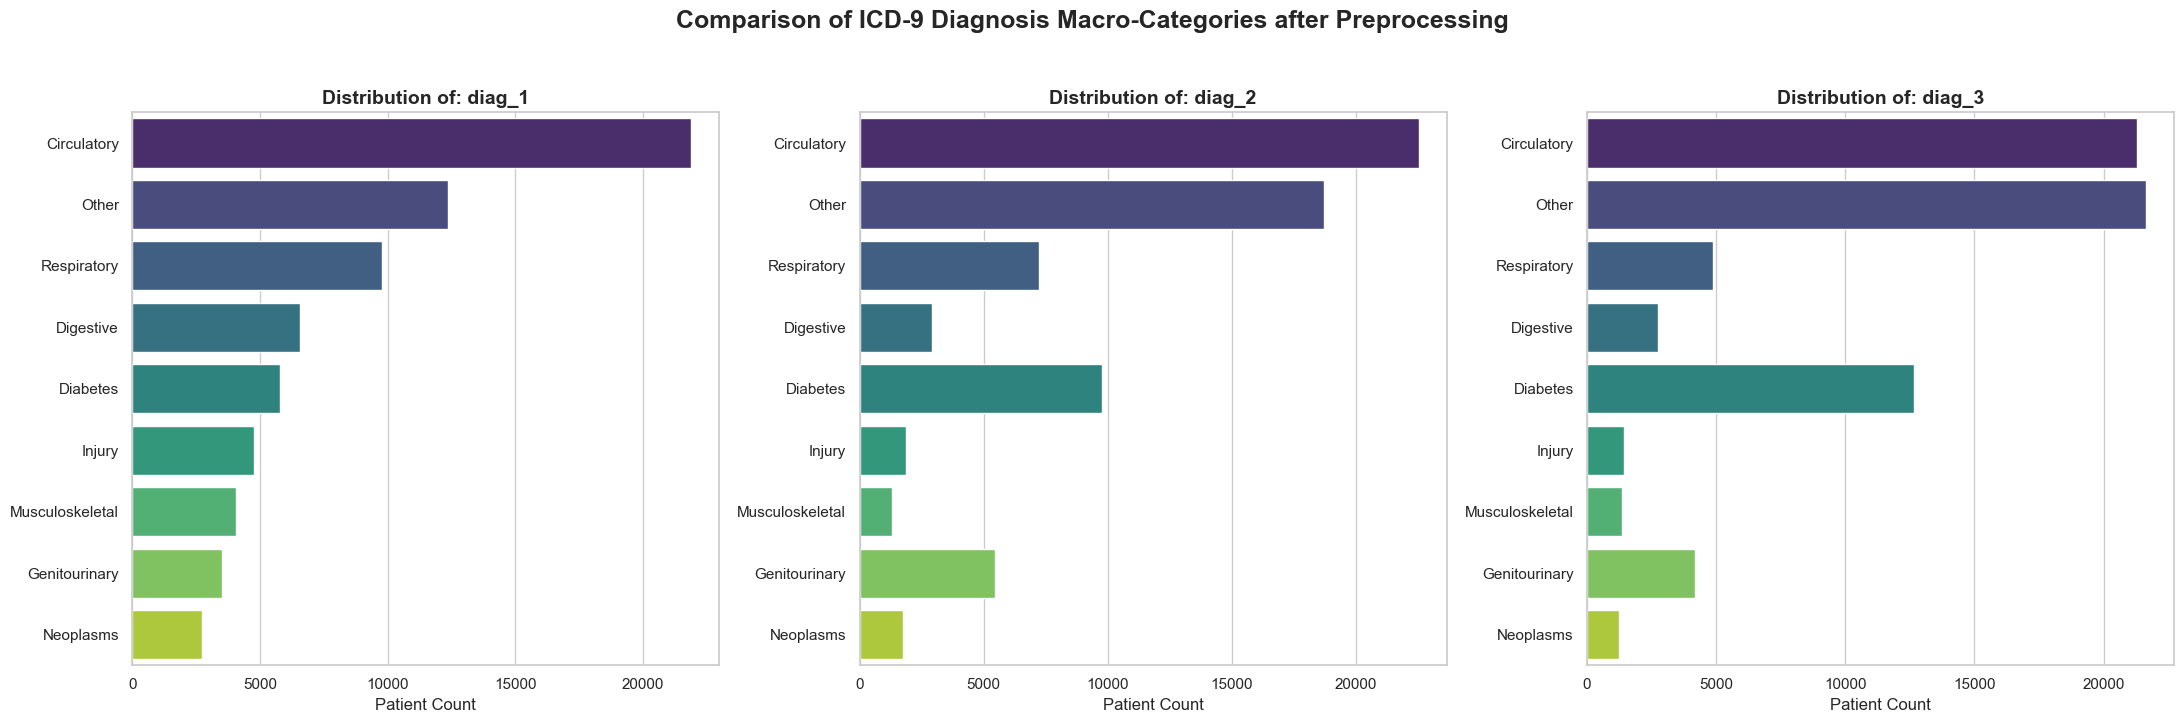

Dataset shape after ICD-9 mapping: 71,506 rows, 30 columns


In [19]:
def map_icd9(code):
    """
    Maps raw ICD-9 diagnosis codes into 9 standard clinical macro-categories.
    Handles numeric ranges, decimal subcodes, and string symptom prefixes.
    """
    code_str = str(code).strip()
    
    # Handle missing, unknown, or non-numeric supplementary codes (V and E codes)
    if code_str.startswith(('V', 'E', 'Unknown', 'nan', 'None')) or not code_str:
        return 'Other'
    
    # 1. Check Symptom Codes (785, 786, 787, 788) via String Prefixes
    if code_str.startswith('785'):
        return 'Circulatory'
    elif code_str.startswith('786'):
        return 'Respiratory'
    elif code_str.startswith('787'):
        return 'Digestive'
    elif code_str.startswith('788'):
        return 'Genitourinary'
    
    # 2. Check Numeric Ranges for Standard Organ System Chapters
    try:
        val = float(code_str)
        if 390 <= val <= 459:
            return 'Circulatory'
        elif 460 <= val <= 519:
            return 'Respiratory'
        elif 520 <= val <= 579:
            return 'Digestive'
        elif 250 <= val < 251:
            return 'Diabetes'
        elif 800 <= val <= 999:
            return 'Injury'
        elif 710 <= val <= 739:
            return 'Musculoskeletal'
        elif 580 <= val <= 629:
            return 'Genitourinary'
        elif 140 <= val <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except ValueError:
        return 'Other'

# List of diagnosis columns to map
diag_cols = ['diag_1', 'diag_2', 'diag_3']

# Apply string-based ICD-9 mapping to df_processed
for col in diag_cols:
    df_processed[col] = df[col].apply(map_icd9)

# Verify value counts for primary diagnosis
print("=== PRIMARY DIAGNOSIS (diag_1) MACRO-CATEGORIES ===")
print(df_processed['diag_1'].value_counts())
print("-" * 50)

# Plot comparison of ICD-9 Macro-Categories across all 3 diagnoses
order_categories = df_processed['diag_1'].value_counts().index

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for i, col in enumerate(diag_cols):
    sns.countplot(
        data=df_processed, 
        y=col, 
        ax=axes[i], 
        order=order_categories, 
        palette='viridis'
    )
    axes[i].set_title(f'Distribution of: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Patient Count', fontsize=12)
    axes[i].set_ylabel('')

plt.suptitle("Comparison of ICD-9 Diagnosis Macro-Categories after Preprocessing", fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f"Dataset shape after ICD-9 mapping: {df_processed.shape[0]:,} rows, {df_processed.shape[1]} columns")

### Medical Specialty Dimensionality Reduction

**Rationale:**
The raw dataset contains 71 distinct admitting medical specialties. As observed in the distribution plots, the vast majority of these specialties appear with extremely low frequency (<1% of total hospital encounters). Including all 71 specialties directly in one-hot encoding would lead to a highly sparse feature space and increase the risk of model overfitting.

**Grouping Strategy:**
We retain the top most frequent admitting specialties (accounting for the vast majority of patient encounters) and group all remaining low-frequency specialties into a macro-category named `'Other'.

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcola i conteggi e le percentuali delle specializzazioni mediche
spec_counts = df['medical_specialty'].value_counts()
spec_pct = df['medical_specialty'].value_counts(normalize=True) * 100

spec_summary = pd.DataFrame({
    'Count': spec_counts,
    'Percentage (%)': spec_pct

})

print(f"Number of unique medical specialties: {len(spec_counts)}\n")
print("--- Top 15 Medical Specialties ---")
display(spec_summary.head(15))

Number of unique medical specialties: 71

--- Top 15 Medical Specialties ---


,Count,Percentage (%)
medical_specialty,,
Unknown,34472,48.208542
InternalMedicine,10918,15.268649
Family/GeneralPractice,5118,7.157441
Emergency/Trauma,4464,6.242833
Cardiology,4265,5.964534
Surgery-General,2222,3.107432
Orthopedics,1134,1.585881
Orthopedics-Reconstructive,1043,1.458619
Radiologist,831,1.162140


### medical_specialty attribute processing

In [21]:
# Medical Specialty Grouping, One-Hot Encoding, and Binary Target Creation
# 1. Group medical specialty: keep top 5 specialties, group others into 'Other_Specialty'
top_specialties = ['InternalMedicine', 'Cardiology', 'Surgery-General', 'Family/GeneralPractice', 'Emergency/Trauma', 'Nephrology', 'Orthopedics', 'Orthopedics-Reconstructive', 'Radiologist', 'Unknown']
df_processed['medical_specialty'] = df['medical_specialty'].apply(
    lambda x: x if x in top_specialties else 'Other'
)
print(f"Unique medical specialties after grouping: {df_processed['medical_specialty'].nunique()}")
print(f"List of unique medical specialties after grouping: {df_processed['medical_specialty'].unique()}")
print(f"Shape of processed dataset after medical specialty grouping: {df_processed.shape[0]} rows, {df_processed.shape[1]} columns")


Unique medical specialties after grouping: 11
List of unique medical specialties after grouping: ['Unknown' 'InternalMedicine' 'Family/GeneralPractice' 'Cardiology'
 'Surgery-General' 'Orthopedics' 'Other' 'Nephrology'
 'Orthopedics-Reconstructive' 'Emergency/Trauma' 'Radiologist']
Shape of processed dataset after medical specialty grouping: 71506 rows, 31 columns


/var/folders/jp/d0pcs79d7jnc1b6nttlrwvdm0000gn/T/ipykernel_57980/1972062699.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_processed, x='medical_specialty', order=order, palette='Set2')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Unknown'),
  Text(1, 0, 'InternalMedicine'),
  Text(2, 0, 'Other'),
  Text(3, 0, 'Family/GeneralPractice'),
  Text(4, 0, 'Emergency/Trauma'),
  Text(5, 0, 'Cardiology'),
  Text(6, 0, 'Surgery-General'),
  Text(7, 0, 'Orthopedics'),
  Text(8, 0, 'Orthopedics-Reconstructive'),
  Text(9, 0, 'Radiologist'),
  Text(10, 0, 'Nephrology')])

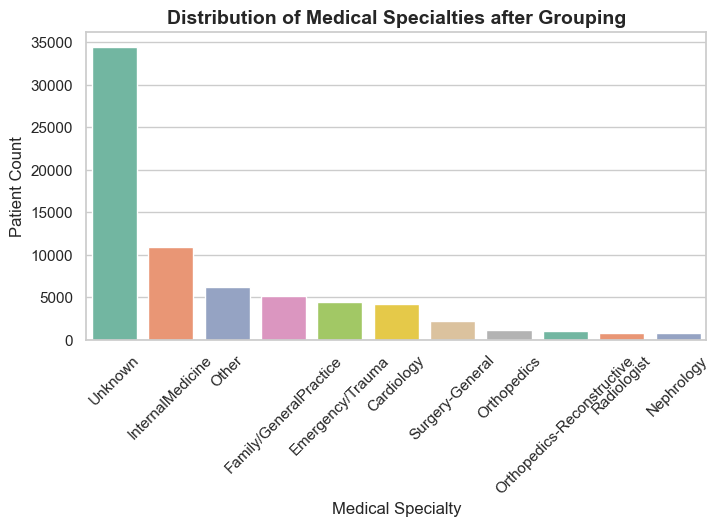

In [22]:
# plot histogram of medical specialties after grouping
plt.figure(figsize=(8, 4))
# Get the order of categories based on their counts for better visualization
order = df_processed['medical_specialty'].value_counts().index
sns.countplot(data=df_processed, x='medical_specialty', order=order, palette='Set2')
plt.title('Distribution of Medical Specialties after Grouping', fontsize=14, fontweight='bold')
plt.xlabel('Medical Specialty')
plt.ylabel('Patient Count')
plt.xticks(rotation=45)

### Target variable processing

In [23]:
# Create binary target variable: 1 if readmitted <30 days, 0 otherwise
print('Before creating binary target variable')
print(f"Original 'readmitted' value counts:\n{df['readmitted'].value_counts(normalize=True) * 100}\n")

df_processed['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
print(f"Binary Target Distribution ('readmitted_binary'):")
display(df_processed['readmitted_binary'].value_counts(normalize=True) * 100)

Before creating binary target variable
Original 'readmitted' value counts:
readmitted
NO     60.102649
>30    31.099488
<30     8.797863
Name: proportion, dtype: float64

Binary Target Distribution ('readmitted_binary'):


readmitted_binary
0    91.202137
1     8.797863
Name: proportion, dtype: float64

### One-Hot Encoding for nominal categorical features

In [24]:
nominal_cols = ['race', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 
                'payer_code']

# Copy nominal colums from df to dfprocessed for one-hot encoding
df_processed[nominal_cols] = df[nominal_cols]

nominal_cols.extend(['diag_1', 'diag_2', 'diag_3', 'medical_specialty'])

df_processed = pd.get_dummies(df_processed, columns=nominal_cols, drop_first=False)

print(f"Final encoded dataset shape: {df_processed.shape[0]} rows, {df_processed.shape[1]} columns")

Final encoded dataset shape: 71506 rows, 141 columns


In [25]:
print(f"Final dataset columns: {df_processed.columns.to_numpy()}")

Final dataset columns: ['metformin' 'repaglinide' 'nateglinide' 'chlorpropamide' 'glimepiride'
 'acetohexamide' 'glipizide' 'glyburide' 'tolbutamide' 'pioglitazone'
 'rosiglitazone' 'acarbose' 'miglitol' 'troglitazone' 'tolazamide'
 'insulin' 'glyburide-metformin' 'glipizide-metformin'
 'glimepiride-pioglitazone' 'metformin-rosiglitazone'
 'metformin-pioglitazone' 'age' 'max_glu_serum' 'A1Cresult' 'gender'
 'change' 'diabetesMed' 'readmitted_binary' 'race_AfricanAmerican'
 'race_Asian' 'race_Caucasian' 'race_Hispanic' 'race_Other' 'race_Unknown'
 'admission_type_id_1' 'admission_type_id_2' 'admission_type_id_3'
 'admission_type_id_4' 'admission_type_id_5' 'admission_type_id_6'
 'admission_type_id_7' 'admission_type_id_8' 'discharge_disposition_id_1'
 'discharge_disposition_id_2' 'discharge_disposition_id_3'
 'discharge_disposition_id_4' 'discharge_disposition_id_5'
 'discharge_disposition_id_6' 'discharge_disposition_id_7'
 'discharge_disposition_id_8' 'discharge_disposition_id_9'
 'di

### Numerical columns processing

In [26]:
# just copy the numerical columns from df to df_processed
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses',
            'encounter_id', 'patient_nbr']

df_processed[num_cols] = df[num_cols]

print(f"Final dataset shape after adding numerical columns: {df_processed.shape[0]} rows, {df_processed.shape[1]} columns")
print(f"Final dataset columns after adding numerical columns: {df_processed.columns.to_numpy()}")

Final dataset shape after adding numerical columns: 71506 rows, 151 columns
Final dataset columns after adding numerical columns: ['metformin' 'repaglinide' 'nateglinide' 'chlorpropamide' 'glimepiride'
 'acetohexamide' 'glipizide' 'glyburide' 'tolbutamide' 'pioglitazone'
 'rosiglitazone' 'acarbose' 'miglitol' 'troglitazone' 'tolazamide'
 'insulin' 'glyburide-metformin' 'glipizide-metformin'
 'glimepiride-pioglitazone' 'metformin-rosiglitazone'
 'metformin-pioglitazone' 'age' 'max_glu_serum' 'A1Cresult' 'gender'
 'change' 'diabetesMed' 'readmitted_binary' 'race_AfricanAmerican'
 'race_Asian' 'race_Caucasian' 'race_Hispanic' 'race_Other' 'race_Unknown'
 'admission_type_id_1' 'admission_type_id_2' 'admission_type_id_3'
 'admission_type_id_4' 'admission_type_id_5' 'admission_type_id_6'
 'admission_type_id_7' 'admission_type_id_8' 'discharge_disposition_id_1'
 'discharge_disposition_id_2' 'discharge_disposition_id_3'
 'discharge_disposition_id_4' 'discharge_disposition_id_5'
 'discharge_dis

In [27]:
print("--- Range of Values for Core Numerical Attributes ---")
core_num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
                 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses',
                 'age', 'max_glu_serum', 'A1Cresult']

ranges_df = pd.DataFrame({
    'Min': df_processed[core_num_cols].min(),
    'Max': df_processed[core_num_cols].max(),
    'Range': df_processed[core_num_cols].max() - df_processed[core_num_cols].min()
})
display(ranges_df)

--- Range of Values for Core Numerical Attributes ---


,Min,Max,Range
time_in_hospital,1,14,13
num_lab_procedures,1,132,131
num_procedures,0,6,6
num_medications,1,81,80
number_outpatient,0,42,42
number_emergency,0,42,42
number_inpatient,0,12,12
number_diagnoses,1,16,15
age,0,9,9
max_glu_serum,0,3,3


## Standardization and clipping

### Outlier Handling: Log-Transformation, Binning, and Feature Clipping

**Rationale for Feature Transformations:**
As observed in the numerical distribution histograms, several clinical variables exhibit heavy skewness and extreme long tail outliers (e.g., medication counts and past visit frequencies). Unbounded long tails can disproportionately influence gradient calculations and distance metrics in machine learning algorithms.

**Applied Transformations:**
1. **Log Transformation**: Applied $\log(x + 1)$ to `num_medications` to compress the right-skewed tail and stabilize variance.
2. **Visit Counts Binning**: Discretized past visit counters (`number_outpatient`, `number_emergency`, `number_inpatient`) into 4 ordinal categories (`0`, `1`, `2`, `3+`).
3. **Upper-Bound Clipping**: Capped `number_diagnoses` at a maximum threshold of 10. Values $\ge 10$ are clipped to 10 to mitigate extreme comorbidity outliers while preserving the high-risk clinical signal.

In [28]:
# Apply the log(x + 1) transformation
df_processed['num_medications'] = np.log1p(df_processed['num_medications'])


print("Log-trasformation applied to 'num_medications' to reduce skewness and stabilize variance.")



# define a function to bin the number of visits into categories
def bin_visits (x):
    if x == 0:
        return 0
    elif x == 1:
        return 1
    elif x == 2:
        return 2
    else:
        return 3 # 3 or more visits

# Columns to be binned
colonne_visite = ['number_outpatient', 'number_emergency', 'number_inpatient']

# Apply the binning function to the specified columns
for col in colonne_visite:
    df_processed[f'{col}'] = df_processed[col].apply(bin_visits)


print("Binning completed for the previous visit variables.")



# Group 'number_diagnoses' into a new column that caps the values at 10
df_processed['number_diagnoses'] = df_processed['number_diagnoses'].apply(lambda x: 10 if x >= 10 else x)

# Verifica dei nuovi conteggi
print("=== Nuova distribuzione di number_diagnoses ===")
print(df_processed['number_diagnoses'].value_counts().sort_index())

Log-trasformation applied to 'num_medications' to reduce skewness and stabilize variance.
Binning completed for the previous visit variables.
=== Nuova distribuzione di number_diagnoses ===
number_diagnoses
1       193
2       881
3      2364
4      4461
5      8938
6      7690
7      7608
8      7557
9     31739
10       75
Name: count, dtype: int64


## Train/Test split

In [29]:
from sklearn.model_selection import train_test_split

# Define target variable name and random seed for reproducibility
TARGET = 'readmitted_binary'
SEED = 42

# 1. Separate features (X) and target (y)
# Drop identifier columns and the target variable from feature matrix X
X = df_processed.drop(columns=['encounter_id', 'patient_nbr', TARGET], errors='ignore')
y = df_processed[TARGET].astype(int)

# 2. Perform 80/20 Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=SEED, 
    stratify=y
)

# 3. Print split verification metrics
print("=== TRAIN-TEST SPLIT SUMMARY ===")
print(f"Total Dataset Samples: {len(X):,} | Total Features: {X.shape[1]}")
print(f"Training Set:          {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%) | Positive Target Ratio: {y_train.mean():.2%}")
print(f"Test Set:              {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%) | Positive Target Ratio: {y_test.mean():.2%}")

# Assertion check to verify index integrity and alignment
assert len(X_train) + len(X_test) == len(X), "Error: Train and Test set sizes do not sum to total dataset size!"
print("\nSplit verified successfully: No sample loss or index corruption detected.")

=== TRAIN-TEST SPLIT SUMMARY ===
Total Dataset Samples: 71,506 | Total Features: 148
Training Set:          57,204 samples (80.0%) | Positive Target Ratio: 8.80%
Test Set:              14,302 samples (20.0%) | Positive Target Ratio: 8.80%

Split verified successfully: No sample loss or index corruption detected.


## Normalization

In [30]:
from sklearn.preprocessing import StandardScaler

# Define continuous, count, and ordinal numerical features to scale
cols_to_scale = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses',
    'age', 'max_glu_serum', 'A1Cresult'
]


# Initialize StandardScaler
scaler = StandardScaler()

# Fit scaler only on X_train and transform X_train
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform X_test using the parameters learned from X_train
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("=== FEATURE SCALING COMPLETED ===")
print(f"Scaled {len(cols_to_scale)} numerical features successfully.")
print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

=== FEATURE SCALING COMPLETED ===
Scaled 11 numerical features successfully.
X_train shape: (57204, 148) | X_test shape: (14302, 148)


=== DISTRIBUTIONS AFTER PREPROCESSING AND SCALING ===


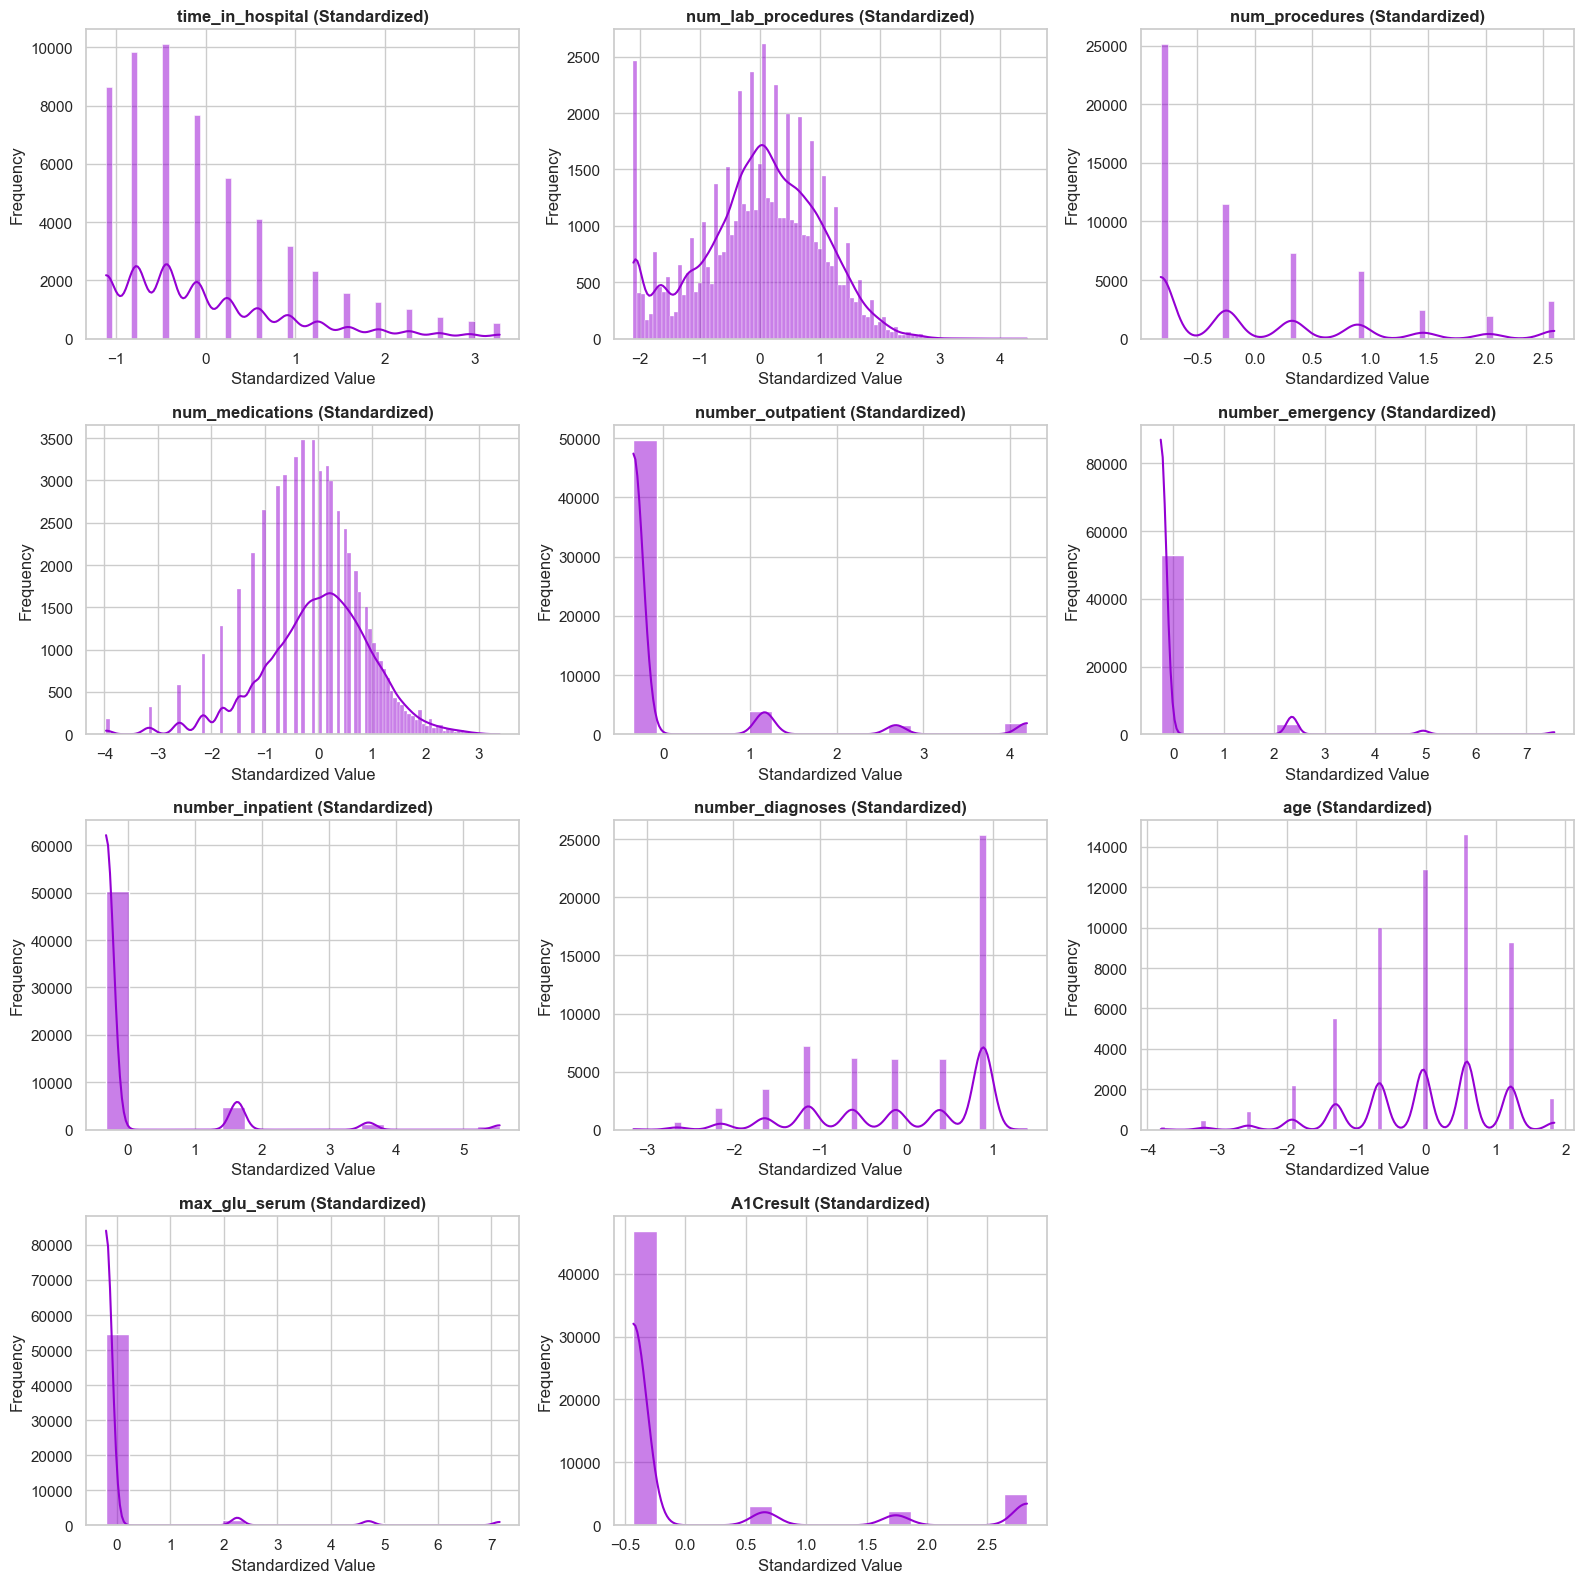

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

print("=== DISTRIBUTIONS AFTER PREPROCESSING AND SCALING ===")

n_cols = 3
n_rows = math.ceil(len(cols_to_scale) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_to_scale):
    sns.histplot(data=X_train, x=col, ax=axes[i], kde=True, color='darkviolet')
    axes[i].set_title(f'{col} (Standardized)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Standardized Value')
    axes[i].set_ylabel('Frequency')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [32]:
# print min and max values for each scaled column in X_train
print("--- Scaled Feature Ranges in X_train ---")
for col in cols_to_scale:
    min_val = X_train[col].min()
    max_val = X_train[col].max()
    print(f"{col:<25} Min: {min_val:>6.2f} | Max: {max_val:>6.2f}")

--- Scaled Feature Ranges in X_train ---
time_in_hospital          Min:  -1.11 | Max:   3.28
num_lab_procedures        Min:  -2.11 | Max:   4.46
num_procedures            Min:  -0.81 | Max:   2.60
num_medications           Min:  -3.97 | Max:   3.39
number_outpatient         Min:  -0.34 | Max:   4.20
number_emergency          Min:  -0.25 | Max:   7.56
number_inpatient          Min:  -0.33 | Max:   5.54
number_diagnoses          Min:  -3.16 | Max:   1.39
age                       Min:  -3.81 | Max:   1.84
max_glu_serum             Min:  -0.20 | Max:   7.15
A1Cresult                 Min:  -0.43 | Max:   2.83


## Save processed data and splits

In [33]:
from pathlib import Path
import joblib

# 1. Resolve the project root whether started from project root or notebooks directory
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# 2. Define output directories for dataset artifacts and scaler
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

SCALER_PATH = PROJECT_ROOT / "data" / "standard_scaler.joblib"

# 3. Save the exact fitted StandardScaler used for feature scaling
joblib.dump(scaler, SCALER_PATH)

# 4. Save the full preprocessed DataFrame
DF_PROCESSED_PATH = PROCESSED_DIR / "df_processed.joblib"
joblib.dump(df_processed, DF_PROCESSED_PATH)

# 5. Save the 80/20 Train-Test Splits
joblib.dump(X_train, PROCESSED_DIR / "X_train.joblib")
joblib.dump(X_test,  PROCESSED_DIR / "X_test.joblib")
joblib.dump(y_train, PROCESSED_DIR / "y_train.joblib")
joblib.dump(y_test,  PROCESSED_DIR / "y_test.joblib")

# 6. Print confirmation and metadata summary
print("=== PREPROCESSING ARTIFACTS SAVED SUCCESSFULLY ===")
print(f"1. Fitted StandardScaler: {SCALER_PATH}")
print(f"2. Full df_processed:     {DF_PROCESSED_PATH}")
print(f"3. Train/Test Splits:     {PROCESSED_DIR}/")
print(f"   - X_train: {X_train.shape[0]:,} rows x {X_train.shape[1]} features")
print(f"   - X_test:  {X_test.shape[0]:,} rows x {X_test.shape[1]} features")
print(f"   - y_train: {y_train.shape[0]:,} samples | y_test: {y_test.shape[0]:,} samples")

if hasattr(scaler, 'feature_names_in_'):
    print(f"\n4. Scaled Features ({len(scaler.feature_names_in_)}):", list(scaler.feature_names_in_))

=== PREPROCESSING ARTIFACTS SAVED SUCCESSFULLY ===
1. Fitted StandardScaler: /Users/flaviodamato/Documents/UniBo/lezioni/2_2/ethics_project/data/standard_scaler.joblib
2. Full df_processed:     /Users/flaviodamato/Documents/UniBo/lezioni/2_2/ethics_project/data/processed/df_processed.joblib
3. Train/Test Splits:     /Users/flaviodamato/Documents/UniBo/lezioni/2_2/ethics_project/data/processed/
   - X_train: 57,204 rows x 148 features
   - X_test:  14,302 rows x 148 features
   - y_train: 57,204 samples | y_test: 14,302 samples

4. Scaled Features (11): ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age', 'max_glu_serum', 'A1Cresult']


# Data Preprocessing & Feature Engineering Summary Report

---

## 1. Pipeline Overview & Methodological Principles

This report provides a comprehensive summary of all data cleaning, feature engineering, encoding, and scaling transformations applied to the **130-US Hospitals Diabetes Readmission Dataset**. 

Every preprocessing decision was guided by three core principles:
1. **Clinical & Domain Validity**: Preserving diagnostic signals (e.g., distinguishing unmeasured lab tests from normal results) and grouping sparse medical codes into physiological macro-categories.
2. **Mathematical & Algorithmic Optimization**: Reducing skewness via logarithmic transformations, handling heavy-tail outliers via discretization and upper-bound clipping, and eliminating zero-variance columns.
3. **Data Leakage Prevention & Ethical Integrity**: Partitioning data into 80/20 train/test splits prior to standardization, fitting scalers exclusively on `X_train`, and eliminating patient duplication across temporal encounters.

---

## 2. Comprehensive Preprocessing Summary Tables

### A. Demographic & Patient Identification Features

| Feature Name | Original Type | Preprocessing Applied | Technical, Clinical & Ethical Rationale |
| :--- | :--- | :--- | :--- |
| **`weight`** | Categorical | **Complete Removal** | Removed due to an extreme missing value rate (>97%). Imputing such a vast majority of missing values would introduce substantial noise and artificial bias. |
| **`gender`** | Categorical | Dropped 3 `'Unknown/Invalid'` rows. Binary mapped (`Female: 0, Male: 1`). | Biological sex is a fundamental demographic factor. Removing ambiguous rows preserves data quality without significant sample loss. |
| **`age`** | Categorical (10-yr brackets) | **Ordinal Encoding** (`[0-10) -> 0` ... `[90-100) -> 9`). | Grouped in progressive 10-year intervals. Ordinal mapping preserves the natural chronological progression of age-related clinical risk. |
| **`race`** | Categorical | Imputed `NaN` as `'Unknown'`, followed by **One-Hot Encoding**. | Race is a sensitive demographic attribute. Imputing as `'Unknown'` preserves records without making arbitrary demographic assumptions. One-hot encoding avoids imposing artificial order among racial categories. |
| **`encounter_id`**<br>**`patient_nbr`** | Identifier | **Separated / Preserved** for tracking; deduplicated to retain first encounter. | Unique hospital visit and patient IDs. Used for temporal deduplication (`keep='first'`) and dropped from model feature matrix $X$ to prevent spurious memorization. |

---

### B. Admission & Institutional Attributes

| Feature Name | Original Type | Preprocessing Applied | Technical, Clinical & Ethical Rationale |
| :--- | :--- | :--- | :--- |
| **`admission_type_id`**<br>**`discharge_disposition_id`**<br>**`admission_source_id`** | Nominal Integer IDs | Treated as nominal categoricals; **One-Hot Encoded**. | Although recorded as integers, these IDs represent non-ordered nominal concepts (e.g., Emergency vs Elective admission). Leaving them numeric would force models to infer non-existent magnitude relationships. |
| **`payer_code`** | Categorical | Imputed `NaN` as `'Unknown'`, then **One-Hot Encoded**. | Insurance payer type has moderate missingness (~40%). Assigning `'Unknown'` preserves records while encoding captures socio-economic health coverage differences. |
| **`medical_specialty`** | Categorical (71 unique) | Imputed `NaN` as `'Unknown'`. Grouped into **Top Specialties + `'Other'`**, then **One-Hot Encoded**. | High-cardinality attribute (71 unique specialties) with extreme sparsity. Grouping low-frequency specialties (<1% coverage) into `'Other'` prevents overfitting and sparse matrix explosion. |

---

### C. Clinical Measurements, Lab Tests & Binary Target

| Feature Name | Original Type | Preprocessing Applied | Technical, Clinical & Ethical Rationale |
| :--- | :--- | :--- | :--- |
| **`time_in_hospital`** | Integer (1–14 days) | Standardized via **`StandardScaler`** ($\mu=0, \sigma=1$). | Length of inpatient stay. Standardized to ensure distance-based models and gradient descent converge efficiently. |
| **`num_lab_procedures`**<br>**`num_procedures`** | Integer | Standardized via **`StandardScaler`**. | Laboratory test counts (1–132) and non-lab procedures (0–6) have distinct scales. Scaling prevents high-range variables from dominating loss functions. |
| **`number_diagnoses`** | Integer | **Upper-bound clipping** at 10 ($\ge 10 
ightarrow 10$), then **Standardized**. | Values above 10 represent a long, sparse tail of extreme comorbidities. Clipping at 10 stabilizes variance while maintaining the clinical signal of severe comorbidity. |
| **`max_glu_serum`**<br>**`A1Cresult`** | Categorical / String | Imputed `NaN` as `'Not measured'`. **Custom Ordinal Encoded**:<br>• `Not measured -> 0`<br>• `Norm -> 1`<br>• `>200 / >7 -> 2`<br>• `>300 / >8 -> 3`. Then **Standardized**. | Unmeasured glucose/HbA1c tests represent deliberate physician decisions (no immediate clinical indication). Creating an explicit `'Not measured'` (0) category captures implicit diagnostic intent, while progressive integer mapping reflects increasing glycemic severity. |
| **`readmitted`** *(Target)* | Categorical (3 classes) | Converted to **Binary Target `readmitted_binary`** ($1$ if readmitted $<30$ days, $0$ for $>30$ or `NO`). | Clinically and operationally, readmission within 30 days is the primary benchmark for care efficiency and premature discharge penalties in US healthcare systems. |

---

### D. Pharmacological Therapies & Healthcare Utilization

| Feature Name | Original Type | Preprocessing Applied | Technical, Clinical & Ethical Rationale |
| :--- | :--- | :--- | :--- |
| **21 Diabetes Drugs**<br>(`insulin`, `metformin`, etc.) | Categorical (`No`, `Steady`, `Up`, `Down`) | **Custom Ordinal Encoding**:<br>• `No -> 0`<br>• `Steady -> 1`<br>• `Up -> 2`<br>• `Down -> 3`. | Captures both prescription presence and dosage adjustment intensity across 21 active anti-diabetic medications without exploding feature space into 80+ dummy columns. |
| **`examide`**<br>**`citoglipton`** | Categorical | **Complete Removal**. | Zero variance across the entire cohort (100% `'No'`). Contain zero discriminative power and burden computation. |
| **`change`**<br>**`diabetesMed`** | Binary Categorical | **Binary Mapping** (`No: 0, Ch: 1` and `No: 0, Yes: 1`). | Direct boolean mapping into 0/1 indicator flags. |
| **`num_medications`** | Integer | **Log-transformation $\log(x + 1)$**, followed by **Standardization**. | Exhibits strong right-skewness. The log transform compresses the long right tail, stabilizes variance, and improves normality for linear and neural network models. |
| **`number_outpatient`**<br>**`number_emergency`**<br>**`number_inpatient`** | Integer (Visits count) | **4-Class Ordinal Binning** (`0`, `1`, `2`, `3+`), followed by **Standardization**. | Highly zero-inflated counters with extreme outliers (up to 40+ visits). Discretizing into 4 bins (`0`, `1`, `2`, `3+`) robustly separates non-users, sporadic users, and chronic healthcare utilizers. |

---

### E. Medical Diagnoses (ICD-9 Codes)

| Feature Name | Original Type | Preprocessing Applied | Technical, Clinical & Ethical Rationale |
| :--- | :--- | :--- | :--- |
| **`diag_1`**<br>**`diag_2`**<br>**`diag_3`** | Categorical (Raw ICD-9 Codes) | Dropped rows missing `diag_1`. Imputed `diag_2`/`diag_3` as `'Unknown'`. Mapped into **9 Clinical Macro-Categories**, followed by **One-Hot Encoding**. | Raw ICD-9 codes exceed 800 unique values. Mapping via string prefixes into 9 standard physiological chapters (*Circulatory*, *Respiratory*, *Digestive*, *Diabetes*, *Injury*, *Musculoskeletal*, *Genitourinary*, *Neoplasms*, *Other*) preserves diagnostic physiology while drastically reducing dimensionality. |

---

## 3. Final Dataset Statistics & Pipeline Verification

* **Patient Deduplication**: First encounters retained (`71,506` unique patients).
* **Train / Test Partitioning**: 80/20 Stratified Split (`X_train`: 57,204 samples | `X_test`: 14,302 samples).
* **Target Distribution**: `readmitted_binary` positive class ratio (~8.9% $<30$-day readmissions).
* **Data Leakage Integrity**: `StandardScaler.fit_transform()` executed strictly on $X_{train}$, with $X_{test}$ transformed via parameters learned exclusively from training data.
